# Detekcja naczyń krwionośnych w dnie oka


In [1]:
%load_ext autoreload
%autoreload 2
%aimport -gui_app
%aimport -gui_guard
%aimport -dnn_processing

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from image_processing import preprocess_image, segment_vessels, get_overlay
from evaluation import calculate_metrics
from gui_guard import training_lock, holdout_lock

In [2]:
IMAGES_DIR = 'data/images'
MANUAL_DIR = 'data/manual'
MASK_DIR = 'data/mask'

def get_image_list():
    return sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

image_list = get_image_list()

In [3]:
from ml_processing import MLVesselSegmenter, prepare_dataset
from dnn_processing import DNNVesselSegmenter, prepare_dnn_dataset, TF_AVAILABLE

ML_MODEL_PATH = 'vessel_ml.joblib'
DNN_MODEL_PATH = 'vessel_cnn.h5'

ml_segmenter = MLVesselSegmenter(patch_size=5)
is_ml_trained = False

if TF_AVAILABLE:
    dnn_segmenter = DNNVesselSegmenter(patch_size=5)
    is_dnn_trained = False
else:
    dnn_segmenter = None
    is_dnn_trained = False
    print("UWAGA: brak TensorFlow — wymaganie 5.0 niedostępne. Zainstaluj: pip install tensorflow")


def train_ml_model(num_train, force=False):
    global is_ml_trained
    with training_lock:
        if is_ml_trained and not force:
            return
        print(f"Trenowanie modelu ML na {num_train} zdjęciach...")
        train_images = image_list[:num_train]
        image_paths = [os.path.join(IMAGES_DIR, f) for f in train_images]
        manual_paths = [os.path.join(MANUAL_DIR, os.path.splitext(f)[0] + ".tif") for f in train_images]
        mask_paths = [os.path.join(MASK_DIR, os.path.splitext(f)[0] + "_mask.tif") for f in train_images]
        X, y = prepare_dataset(image_paths, manual_paths, mask_paths, patch_size=5, max_samples=15000)
        ml_segmenter.train(X, y)
        ml_segmenter.save(ML_MODEL_PATH)
        is_ml_trained = True
        print("Model ML wytrenowany i zapisany.")


def train_dnn_model(num_train, force=False):
    global is_dnn_trained
    if dnn_segmenter is None:
        raise RuntimeError("Zainstaluj TensorFlow: pip install tensorflow")
    with training_lock:
        if is_dnn_trained and not force:
            return
        print(f"Trenowanie modelu CNN na {num_train} zdjęciach...")
        train_images = image_list[:num_train]
        image_paths = [os.path.join(IMAGES_DIR, f) for f in train_images]
        manual_paths = [os.path.join(MANUAL_DIR, os.path.splitext(f)[0] + ".tif") for f in train_images]
        mask_paths = [os.path.join(MASK_DIR, os.path.splitext(f)[0] + "_mask.tif") for f in train_images]
        X, y = prepare_dnn_dataset(image_paths, manual_paths, mask_paths, patch_size=5, max_samples=40000)
        dnn_segmenter.train(X, y, epochs=50, batch_size=512)
        dnn_segmenter.save(DNN_MODEL_PATH)
        is_dnn_trained = True
        print("Model CNN wytrenowany i zapisany.")

if os.path.exists(ML_MODEL_PATH):
    try:
        ml_segmenter.load(ML_MODEL_PATH)
        is_ml_trained = True
    except:
        train_ml_model(20)
else:
    train_ml_model(20)

if TF_AVAILABLE:
    if os.path.exists(DNN_MODEL_PATH):
        try:
            dnn_segmenter.load(DNN_MODEL_PATH)
            is_dnn_trained = True
        except:
            train_dnn_model(20)
    else:
        train_dnn_model(20)


In [7]:
from gui_app import display_gui

display_gui(
    image_list=image_list,
    images_dir=IMAGES_DIR,
    manual_dir=MANUAL_DIR,
    mask_dir=MASK_DIR,
    ml_segmenter=ml_segmenter,
    dnn_segmenter=dnn_segmenter,
    train_ml_model=train_ml_model,
    train_dnn_model=train_dnn_model,
    get_is_ml_trained=lambda: is_ml_trained,
    set_is_ml_trained=lambda value: globals().__setitem__("is_ml_trained", value),
    get_is_dnn_trained=lambda: is_dnn_trained,
    set_is_dnn_trained=lambda value: globals().__setitem__("is_dnn_trained", value),
)


### Ewaluacja Hold-Out


=== EWALUACJA HOLD-OUT ===
Trening: 15 obrazów | Test: 5 obrazów


--- ANALIZA ZDJĘCIA: 14_g.jpg ---


/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(binary_bool, min_size=min_obj_size)
/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous pa

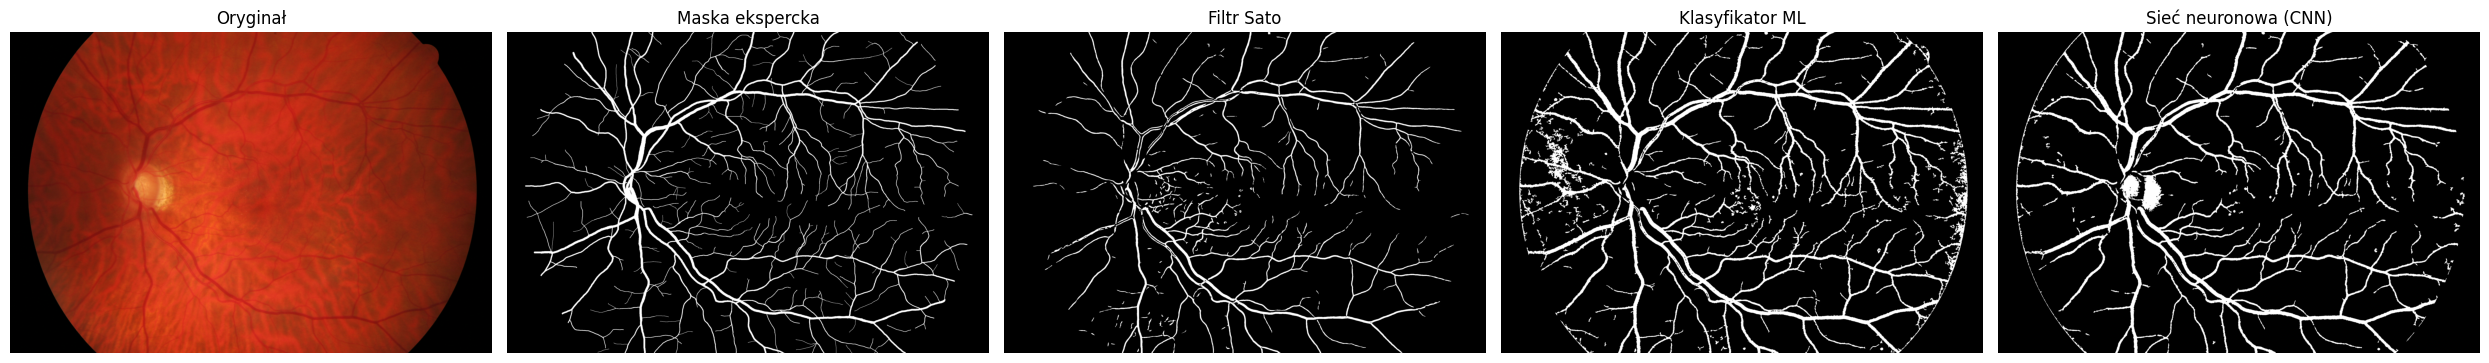

Wyniki dla 14_g.jpg:
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9527   | 0.6192   | 0.9832   | 0.7802  
Klasyfikator ML          | 0.9171   | 0.8421   | 0.9239   | 0.8821  
Sieć neuronowa (CNN)     | 0.9283   | 0.7920   | 0.9407   | 0.8631  


--- ANALIZA ZDJĘCIA: 14_h.jpg ---


/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(binary_bool, min_size=min_obj_size)
/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous pa

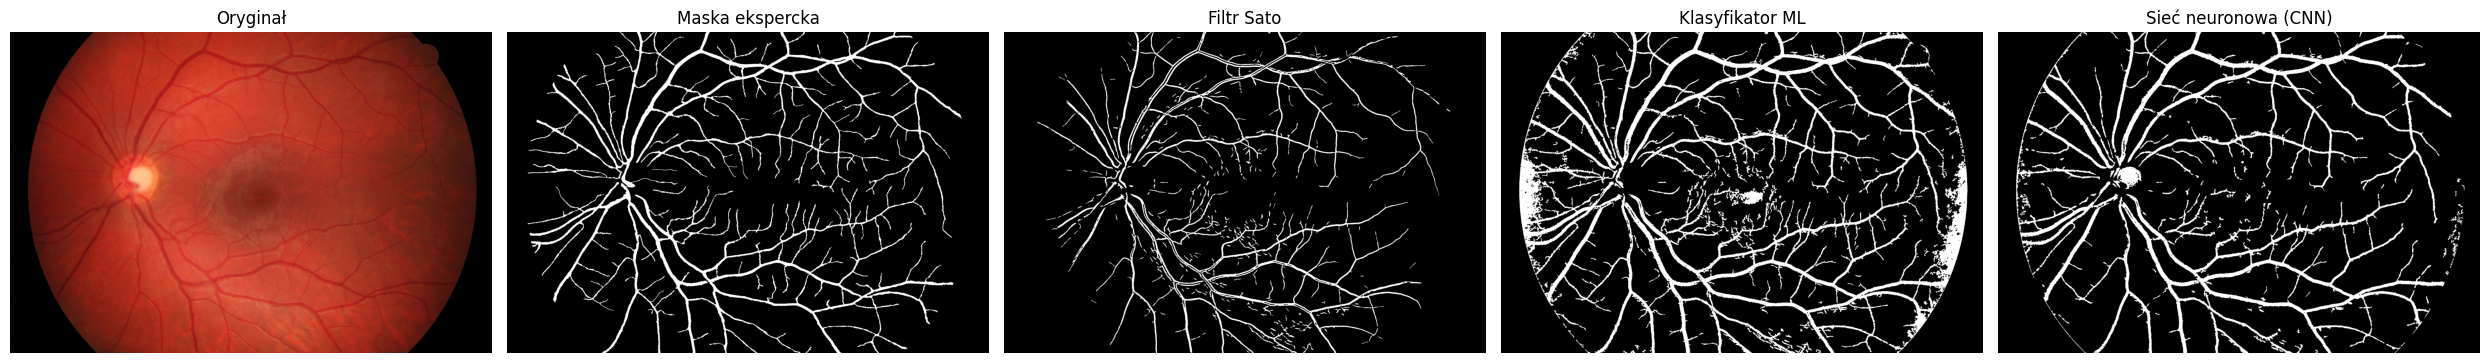

Wyniki dla 14_h.jpg:
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9467   | 0.5990   | 0.9867   | 0.7688  
Klasyfikator ML          | 0.9010   | 0.9078   | 0.9002   | 0.9040  
Sieć neuronowa (CNN)     | 0.9319   | 0.8179   | 0.9451   | 0.8792  


--- ANALIZA ZDJĘCIA: 15_dr.JPG ---


/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(binary_bool, min_size=min_obj_size)
/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous pa

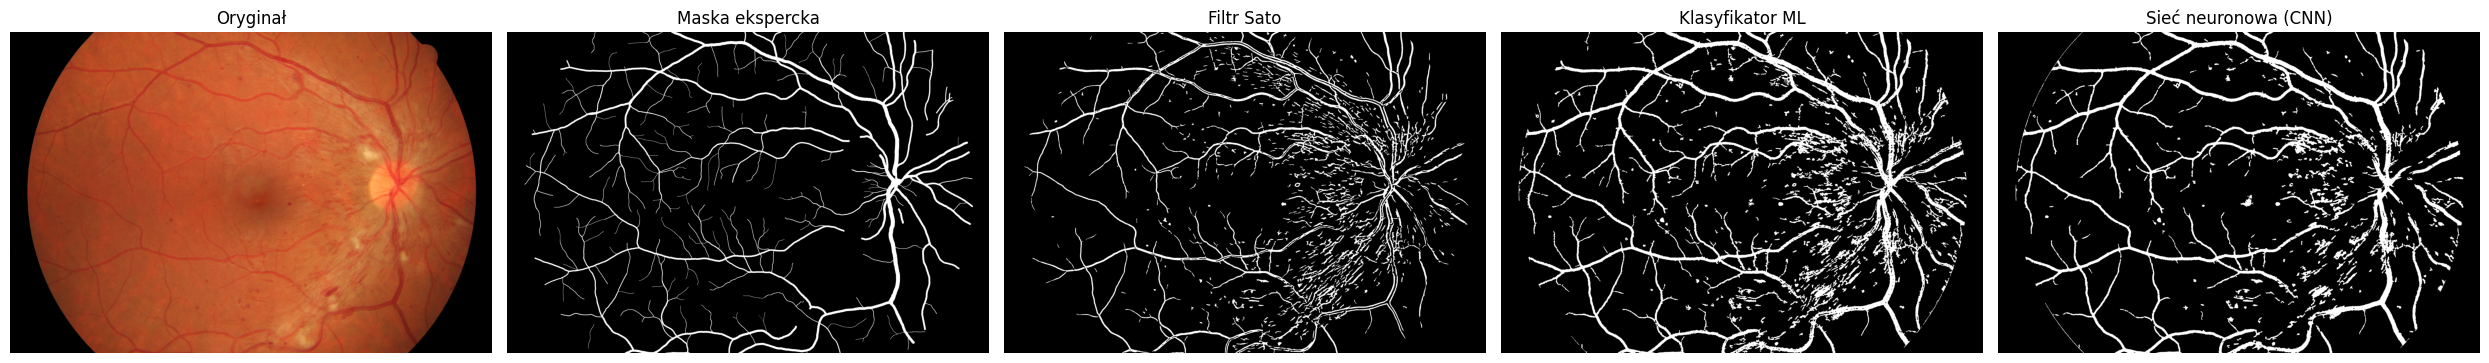

Wyniki dla 15_dr.JPG:
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9233   | 0.6546   | 0.9458   | 0.7869  
Klasyfikator ML          | 0.9012   | 0.8603   | 0.9046   | 0.8822  
Sieć neuronowa (CNN)     | 0.9172   | 0.8047   | 0.9266   | 0.8635  


--- ANALIZA ZDJĘCIA: 15_g.jpg ---


/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(binary_bool, min_size=min_obj_size)
/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous pa

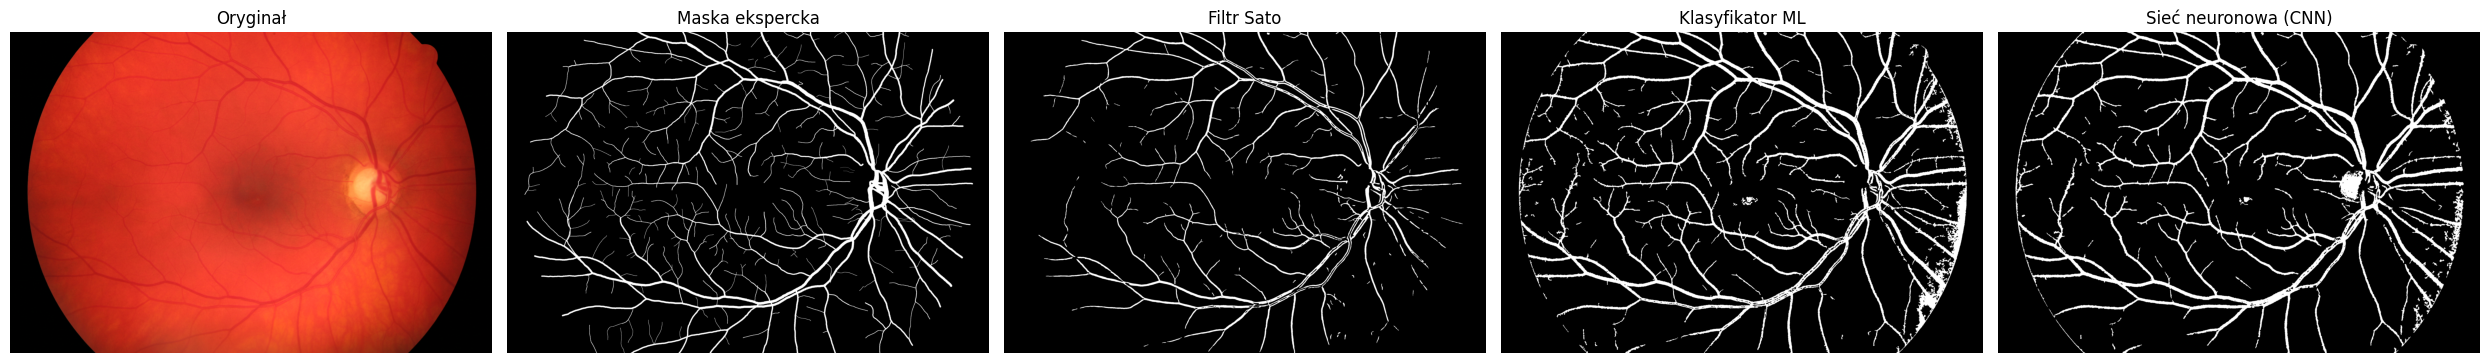

Wyniki dla 15_g.jpg:
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9525   | 0.6023   | 0.9857   | 0.7705  
Klasyfikator ML          | 0.9236   | 0.8267   | 0.9327   | 0.8781  
Sieć neuronowa (CNN)     | 0.9245   | 0.8031   | 0.9360   | 0.8670  


--- ANALIZA ZDJĘCIA: 15_h.jpg ---


/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = remove_small_objects(binary_bool, min_size=min_obj_size)
/Users/krzysztofzaporowski/Desktop/Studia/InformatykaWMedycynie/dno_oka/image_processing.py:83: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous pa

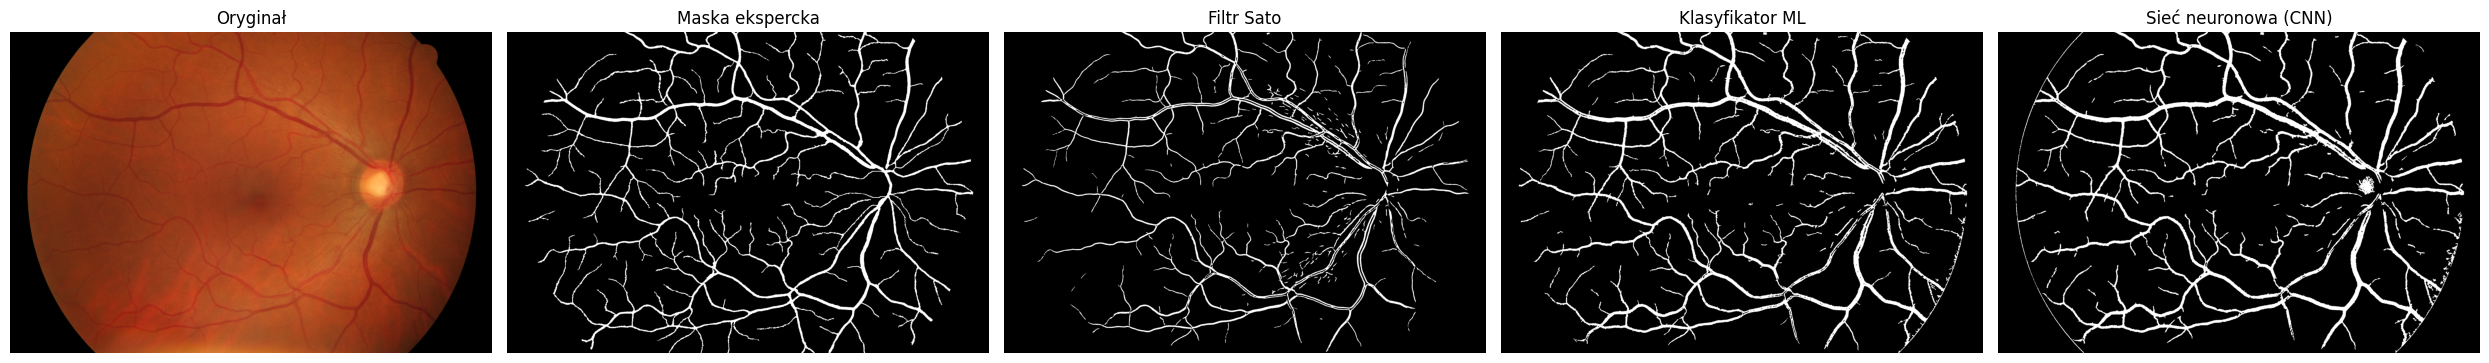

Wyniki dla 15_h.jpg:
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9587   | 0.6480   | 0.9905   | 0.8012  
Klasyfikator ML          | 0.9535   | 0.8157   | 0.9675   | 0.8884  
Sieć neuronowa (CNN)     | 0.9446   | 0.8134   | 0.9580   | 0.8827  

       PODSUMOWANIE (średnie na zbiorze testowym)        
Metoda                   | Acc      | Sens     | Spec     | G-Mean  
---------------------------------------------------------
Filtr Sato               | 0.9468   | 0.6246   | 0.9784   | 0.7815  
Klasyfikator ML          | 0.9193   | 0.8505   | 0.9258   | 0.8869  
Sieć neuronowa (CNN)     | 0.9293   | 0.8062   | 0.9413   | 0.8711  


In [6]:
from gui_app import get_num_images_slider


def run_holdout_evaluation():
    if not holdout_lock.acquire(blocking=False):
        print('Ewaluacja hold-out już trwa.')
        return
    try:
        if not is_ml_trained:
            print('Modele nie są wytrenowane! Kliknij Uruchom analizę w GUI.')
            return
        if not is_dnn_trained:
            print('CNN nie jest wytrenowana! Kliknij Uruchom analizę w GUI.')
            return

        num_images_to_train = get_num_images_slider()
        if num_images_to_train is None:
            print('Najpierw uruchom komórkę GUI powyżej.')
            return

        n_train = num_images_to_train.value
        test_images = image_list[-5:]

        if len(test_images) == 0:
            print('Brak zdjęć testowych! Zmniejsz slider.')
            return

        print('=== EWALUACJA HOLD-OUT ===')
        print(f'Trening: {n_train} obrazów | Test: {len(test_images)} obrazów')
        print()

        methods = ['Filtr Sato', 'Klasyfikator ML', 'Sieć neuronowa (CNN)']
        all_results = {m: [] for m in methods}

        for img_name in test_images:
            img_path = os.path.join(IMAGES_DIR, img_name)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            base_name = os.path.splitext(img_name)[0]
            manual_mask = cv2.imread(os.path.join(MANUAL_DIR, base_name + '.tif'), cv2.IMREAD_GRAYSCALE)
            fov_mask = cv2.imread(os.path.join(MASK_DIR, base_name + '_mask.tif'), cv2.IMREAD_GRAYSCALE)
            preprocessed = preprocess_image(image_rgb)

            print(f'\n--- ANALIZA ZDJĘCIA: {img_name} ---')
            
            fig, axes = plt.subplots(1, 5, figsize=(25, 5))
            axes[0].imshow(image_rgb)
            axes[0].set_title('Oryginał')
            axes[1].imshow(manual_mask, cmap='gray')
            axes[1].set_title('Maska ekspercka')

            current_img_metrics = []

            for i, method in enumerate(methods):
                detected = segment_vessels(
                    preprocessed, method=method, mask=fov_mask,
                    ml_segmenter=ml_segmenter, dnn_segmenter=dnn_segmenter,
                )
                metrics = calculate_metrics(manual_mask, detected, mask=fov_mask)
                all_results[method].append({
                    'image': img_name,
                    'accuracy': metrics['accuracy'],
                    'sensitivity': metrics['sensitivity'],
                    'specificity': metrics['specificity'],
                    'g_mean': metrics['g_mean'],
                })
                current_img_metrics.append((method, metrics))
                
                axes[i+2].imshow(detected, cmap='gray')
                axes[i+2].set_title(f"{method}")

            for ax in axes:
                ax.axis('off')
            plt.tight_layout()
            plt.show()

            print(f'Wyniki dla {img_name}:')
            print(f'{"Metoda":<24} | {"Acc":<8} | {"Sens":<8} | {"Spec":<8} | {"G-Mean":<8}')
            print('-' * 57)
            for method_name, m in current_img_metrics:
                print(f'{method_name:<24} | {m["accuracy"]:<8.4f} | {m["sensitivity"]:<8.4f} | {m["specificity"]:<8.4f} | {m["g_mean"]:<8.4f}')
            print()

        print('=' * 57)
        print(f'{"PODSUMOWANIE (średnie na zbiorze testowym)":^57}')
        print('=' * 57)
        print(f'{"Metoda":<24} | {"Acc":<8} | {"Sens":<8} | {"Spec":<8} | {"G-Mean":<8}')
        print('-' * 57)
        for method in methods:
            res = all_results[method]
            if res:
                print(
                    f'{method:<24} | '
                    f'{np.mean([r["accuracy"] for r in res]):<8.4f} | '
                    f'{np.mean([r["sensitivity"] for r in res]):<8.4f} | '
                    f'{np.mean([r["specificity"] for r in res]):<8.4f} | '
                    f'{np.mean([r["g_mean"] for r in res]):<8.4f}'
                )
    finally:
        holdout_lock.release()


run_holdout_evaluation()
